In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import heapq
from collections import Counter
import math

In [2]:
img = cv2.imread("flower.jpg", cv2.IMREAD_GRAYSCALE)
img

array([[ 15,  15,  15, ...,  90, 100, 106],
       [ 15,  15,  15, ...,  90, 100, 106],
       [ 14,  15,  15, ...,  90, 100, 106],
       ...,
       [ 18,  19,  19, ...,   0,   0,   0],
       [ 18,  19,  19, ...,   0,   0,   0],
       [ 18,  20,  20, ...,   0,   0,   0]], shape=(635, 950), dtype=uint8)

# Entropy Coding

## Huffman Coding

In [17]:
pixels = img.flatten()
total_pixels = len(pixels)

freq = Counter(pixels)

prob = {k: v / total_pixels for k,v in freq.items()}

class Node:
    def __init__(self, symbol, prob):
        self.symbol = symbol
        self.prob = prob
        self.left = None
        self.right = None
    def __lt__(self, other):  #less than constructor
        return self.prob < other.prob

def huffman_tree(prob):
    heap = [Node(symbol, p) for symbol, p in prob.items()]
    heapq.heapify(heap)

    while len(heap) >1:
        n1 = heapq.heappop(heap)
        n2 = heapq.heappop(heap)

        merged = Node(None, n1.prob+n2.prob)
        merged.left = n1
        merged.right = n2

        heapq.heappush(heap, merged)
    return heap[0]

def get_codes(node, current_node= "", codes = None):
    if codes  is None:
        codes = {}
    if node is None:
        return codes
    if node.symbol is not None:
        codes[node.symbol] = current_node
        
    get_codes(node.left, current_node + "0", codes)
    get_codes(node.right, current_node + "1", codes)

    return codes

root = huffman_tree(prob)
codes = get_codes(root)

L_avg = sum(prob[sym] * len(code) for sym, code in codes.items())
entropy = - sum(p* math.log2(p) for p in prob.values())
efficiency = entropy / L_avg * 100
compression_ratio = 8 / L_avg

print("Entropy:", entropy)
print("Average Length Code:", L_avg)
print("Efficiency", efficiency)
print("Compression Ratio", compression_ratio)

print("Huffman Codes:")
for k in sorted(codes):
    print(f"{k}:{codes[k]}")

Entropy: 7.076659194110863
Average Length Code: 7.103312059676751
Efficiency 99.62478256140275
Compression Ratio 1.1262351889921127
Huffman Codes:
0:0010111
1:1111100
2:1010111
3:0011111
4:1000101
5:1011001
6:1011100
7:1001110
8:1010100
9:1101010
10:000101
11:001000
12:001010
13:010011
14:101101
15:00000
16:01111
17:10010
18:01010
19:00110
20:00001
21:111010
22:111011
23:111001
24:110011
25:110110
26:110000
27:101000
28:011011
29:011001
30:010001
31:001110
32:1111110
33:1101111
34:1111111
35:1111001
36:1110000
37:1101001
38:1100011
39:1010010
40:1010011
41:1001100
42:1000111
43:0111011
44:0111010
45:1000100
46:0100100
47:0001111
48:11010000
49:10111011
50:10011010
51:01011101
52:01001010
53:01011110
54:01101000
55:10000100
56:01000011
57:00011100
58:111110100
59:111000110
60:110111011
61:110101110
62:110010000
63:110101101
64:110100010
65:101111101
66:100111101
67:100011010
68:011100011
69:011100001
70:011000110
71:011010011
72:011000011
73:010010111
74:011100110
75:011100000
76:010111

## Runlength Coding

In [27]:
def run_length(row):
    rl = []
    prev_pixel = int(row[0])  #first_pixel
    count = 1

    #traverse along row
    for pixel in row[1:]:
        pixel = int(pixel)
        if pixel == prev_pixel:
            count += 1
        else:
            rl.append((prev_pixel, count))
            prev_pixel = pixel
            count = 1
    rl.append((prev_pixel, count)) # store final run
    return rl

row_index = img.shape[0] // 2 #take center image row to calculate runlength
row = img[row_index]
print(f"Selected Row index: {row_index}")
print(f"Number of pixels: {len(row)}")

rl_encoded = run_length(row)
print("Original Row values:")
print(row.tolist())
print("\n")
print("Runlength Coded: (Pixel value, Run Length)")

for pair in rl_encoded:
    print(pair, end = " ")

print("\n")

original_length = len(row)
compressed_length = len(rl_encoded)

compression_ratio = original_length/compressed_length

print(f"Original Length: {original_length}")
print(f"Compressed Length: {compressed_length}")
print(f"Compression Ratio: {compression_ratio:.2f}:1")

Selected Row index: 317
Number of pixels: 950
Original Row values:
[19, 19, 19, 19, 18, 18, 18, 18, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 19, 19, 20, 20, 21, 22, 23, 23, 22, 22, 22, 22, 22, 22, 23, 23, 25, 24, 23, 23, 24, 24, 24, 23, 25, 25, 25, 26, 26, 26, 26, 26, 26, 26, 26, 25, 25, 26, 26, 26, 27, 27, 27, 28, 28, 28, 28, 28, 28, 28, 28, 28, 29, 29, 29, 29, 29, 29, 29, 29, 30, 30, 30, 30, 31, 31, 31, 31, 31, 31, 31, 31, 29, 29, 29, 29, 29, 29, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 27, 27, 27, 27, 27, 27, 27, 27, 28, 28, 28, 27, 27, 27, 27, 27, 27, 27, 26, 26, 26, 26, 26, 26, 25, 25, 25, 25, 25, 25, 25, 24, 23, 23, 23, 23, 23, 22, 22, 22, 23, 22, 22, 22, 21, 21, 21, 20, 21, 21, 20, 20, 20, 20, 20, 21, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 20, 20, 19, 19, 18, 18, 18, 19, 19, 18, 18, 18, 17, 17, 17, 18, 18, 18, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18, 18, 17, 17, 17, 17, 17, 17, 18, 18, 17, 

## LGW Coding

In [4]:
import pandas as pd

In [30]:
def lzw(values):
    dictionary = {bytes([i]): i for i in range(256)}
    w = b""
    result = []
    code = 256
    steps = []

    for i, byte in enumerate(values): # enumerate returns (index, value)
        wc = w + bytes([byte])
        if wc in dictionary:
            w = wc
        else:
            result.append(dictionary[w])
            steps.append({
            "Currently Recognized Sequence": list(w),
            "Pixel Being Processed": byte,
            "Encoded Output": dictionary[w],
            "Dictionary Location (Code Word)": code,
            "Dictionary Entry": list(wc)
            })
            dictionary[wc] = code
            code += 1
            w = bytes([byte])
    if w:
        result.append(dictionary[w])
    return result, steps

row = img.shape[0] // 2
values = img[row, :50] #taking upto 50 pixels only

print("Original Pixels:")
print(values.tolist())

compressed, steps = lzw(values)
original_bits = len(values) * 8

max_code = max(compressed)
bits_per_code = max_code.bit_length()

compressed_bits = len(compressed) * bits_per_code
compression_ratio = original_bits / compressed_bits

print("\nOriginal Size:", original_bits, "bits")
print("Compressed Size:", compressed_bits, "bits")
print(f"Compression Ratio: {compression_ratio:.2f}:1")

print("\nDictionary Calculation Iterations:")
df = pd.DataFrame(steps)
display(df)

Original Pixels:
[19, 19, 19, 19, 18, 18, 18, 18, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 19, 19, 20, 20, 21, 22, 23, 23, 22, 22, 22, 22, 22, 22, 23, 23, 25, 24, 23, 23, 24, 24, 24, 23, 25, 25]

Original Size: 400 bits
Compressed Size: 279 bits
Compression Ratio: 1.43:1

Dictionary Calculation Iterations:


,Currently Recognized Sequence,Pixel Being Processed,Encoded Output,Dictionary Location (Code Word),Dictionary Entry
0,[19],19,19,256,"[19, 19]"
1,"[19, 19]",19,256,257,"[19, 19, 19]"
2,[19],18,19,258,"[19, 18]"
3,[18],18,18,259,"[18, 18]"
4,"[18, 18]",18,259,260,"[18, 18, 18]"
5,[18],17,18,261,"[18, 17]"
6,[17],17,17,262,"[17, 17]"
7,"[17, 17]",17,262,263,"[17, 17, 17]"
8,"[17, 17]",18,262,264,"[17, 17, 18]"
9,"[18, 18, 18]",18,260,265,"[18, 18, 18, 18]"


# Predictive Coding

Original image size : (635, 950)
Original bits       : 4826000
Prediction Error Min: -188
Prediction Error Max: 163
Bits needed/error   : 9
Compressed bits     : 5429250
Compression Ratio   : 0.89:1
MSE                 : 0.0

First 25 Predictive Coding Steps



,Pixel Position,Actual Pixel,Predicted Pixel,Prediction Error
0,"(0,0)",15,0,15
1,"(0,1)",15,15,0
2,"(0,2)",15,15,0
3,"(0,3)",15,15,0
4,"(0,4)",16,15,1
5,"(0,5)",16,16,0
6,"(0,6)",16,16,0
7,"(0,7)",16,16,0
8,"(0,8)",17,16,1
9,"(0,9)",17,17,0


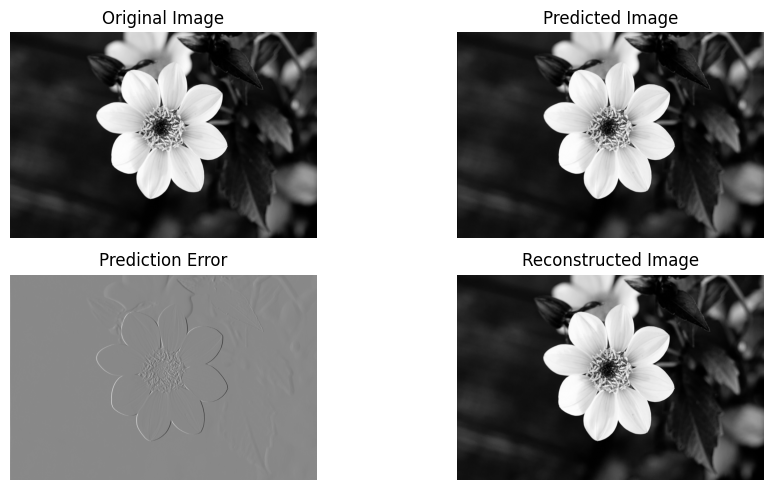

In [7]:
rows, cols = img.shape

prediction = np.zeros_like(img, dtype = np.int16)
error = np.zeros_like(img, dtype = np.int16)

steps = []

for i in range(rows):
    for j in range(cols):
        if j == 0:
            pred = 0 # first column
        else:
            pred = img[i, j-1] #left predictor
        prediction[i,j] = pred

        error[i,j] = int(img[i,j]) - int(pred)

        if len(steps) < 25: # for step visualization of first 25 pixels
            steps.append({
                "Pixel Position": f"({i},{j})",
                "Actual Pixel": int(img[i,j]),
                "Predicted Pixel": int(pred),
                "Prediction Error": int(error[i,j])
            })
reconstructed = np.zeros_like(img, dtype = np.int16)

for i in range(rows):
    for j in range(cols):
        if j == 0:
            pred = 0
        else:
            pred = reconstructed[i,j-1]

        reconstructed[i,j] = pred + error[i,j]

reconstructed = np.clip(reconstructed,0,255).astype(np.uint8)

original_bits = img.size * 8

error_min = np.min(error)
error_max = np.max(error)
error_range = error_max - error_min + 1 
bits_required = int(np.ceil(np.log2(error_range))) # Number of bits required to represent prediction errors

compressed_bits = img.size * bits_required

compression_ratio = original_bits / compressed_bits

mse = np.mean((img.astype(float)-reconstructed.astype(float))**2)

print("Original image size :", img.shape)
print("Original bits       :", original_bits)
print("Prediction Error Min:", error_min)
print("Prediction Error Max:", error_max)
print("Bits needed/error   :", bits_required)
print("Compressed bits     :", compressed_bits)
print("Compression Ratio   : {:.2f}:1".format(compression_ratio))
print("MSE                 :", mse)

df = pd.DataFrame(steps)

print("\nFirst 25 Predictive Coding Steps\n")
display(df)

plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.imshow(img,cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(prediction,cmap='gray')
plt.title("Predicted Image")
plt.axis("off")

plt.subplot(2,2,3)

error_display = error - error.min() # Shift error values for visualization

plt.imshow(error_display,cmap='gray')
plt.title("Prediction Error")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(reconstructed,cmap='gray')
plt.title("Reconstructed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

# Transform Coding

## Hadamard Transform

Image Size : (632, 944)
Block Size : 8
Quantization Step : 10
RMS Error : 1.4298


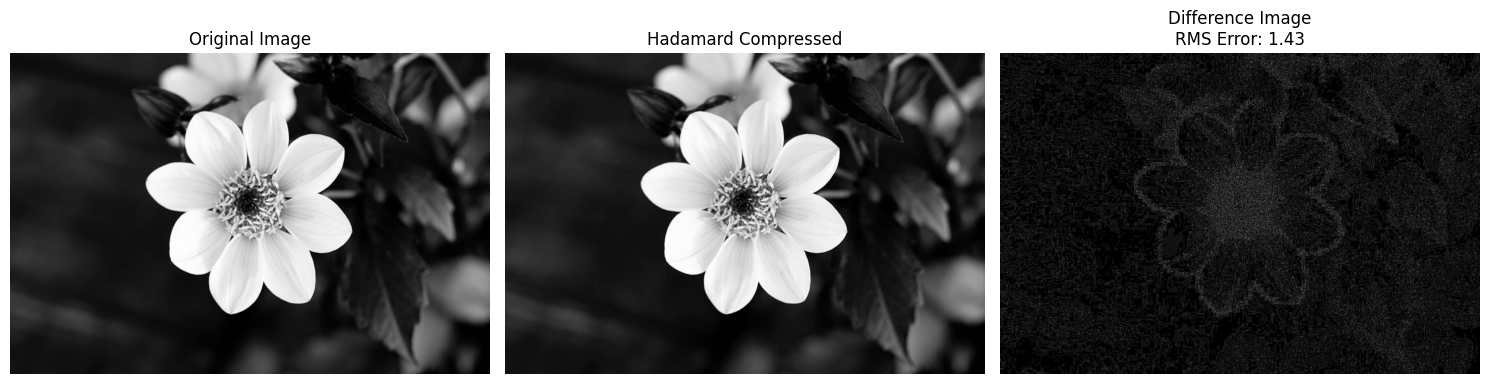

In [4]:
def hadamard_matrix(n):
    if n == 1:
        return np.array([[1]], dtype=np.float32)
    H = hadamard_matrix(n//2)
    return np.block([[H, H],
                     [H,-H]])

def quantizer(x, step):
    return np.round(x/step)

def dequantizer(q, step):
    return q*step

def hadamard_transform(block):
    H = hadamard_matrix(block.shape[0])
    return (H @ block @ H)/block.shape[0]

def inverse_hadamard_transform(block):
    H = hadamard_matrix(block.shape[0])
    return (H @ block @ H)/block.shape[0]

def rms_error(original,reconstructed):
    return np.sqrt(np.mean((original.astype(np.float32)-reconstructed.astype(np.float32))**2))

def hadamard_coding(img, block_size=8, q_step=10):
    h,w = img.shape
    h -= h % block_size
    w -= w % block_size
    original = img[:h,:w]
    reconstructed = np.zeros((h,w),dtype=np.float32)

    for i in range(0,h,block_size):
        for j in range(0,w,block_size):
            block = original[i:i+block_size,j:j+block_size].astype(np.float32)

            coeff = hadamard_transform(block)
            q = quantizer(coeff,q_step)
            dq = dequantizer(q,q_step)
            rec = inverse_hadamard_transform(dq)

            reconstructed[i:i+block_size,j:j+block_size] = rec

    reconstructed = np.clip(reconstructed,0,255).astype(np.uint8)
    return reconstructed, original
block_size = 8
q_step = 10

compressed, original = hadamard_coding(img,block_size,q_step)

rms = rms_error(original,compressed)
diff = cv2.absdiff(original,compressed)

print("Image Size :",original.shape)
print("Block Size :",block_size)
print("Quantization Step :",q_step)
print(f"RMS Error : {rms:.4f}")

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original,cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(compressed,cmap='gray')
plt.title("Hadamard Compressed")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(diff,cmap='gray')
plt.title(f"Difference Image\nRMS Error: {rms:.2f}")
plt.axis("off")

plt.tight_layout()
plt.show()

## Haar Transform

Haar Transform RMS: 1.4959226


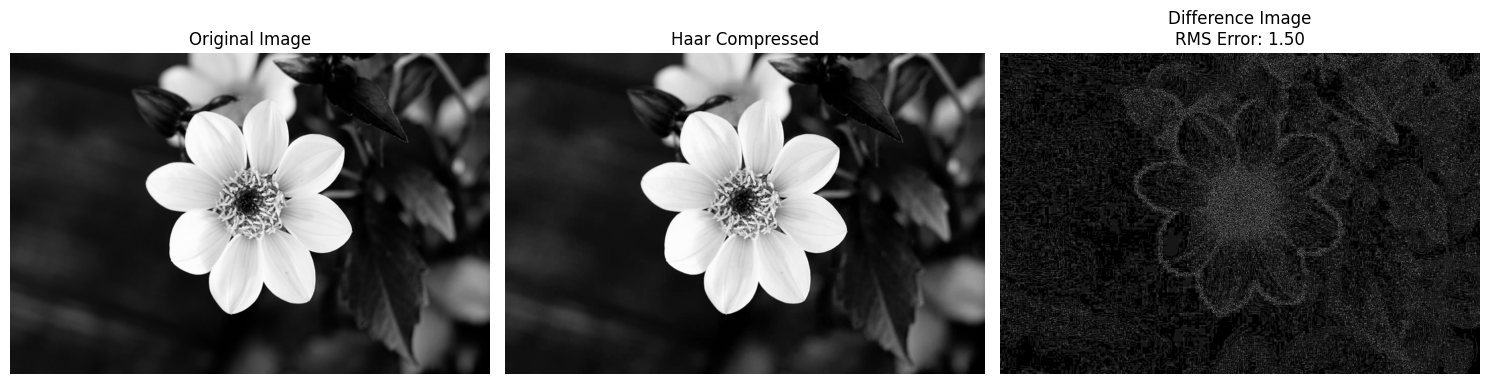

In [5]:
def haar_matrix(n):
    if n==1:
        return np.array([[1.]],dtype=np.float32)
    H=haar_matrix(n//2)
    I=np.eye(n//2,dtype=np.float32)
    top=np.kron(H,[1,1])
    bottom=np.kron(I,[1,-1])
    M=np.vstack((top,bottom))/np.sqrt(2)
    return M

def quantizer(x,s): return np.round(x/s)
def dequantizer(q,s): return q*s

def haar_transform(block):
    H=haar_matrix(block.shape[0])
    return H@block@H.T

def inverse_haar_transform(block):
    H=haar_matrix(block.shape[0])
    return H.T@block@H

def rms_error(a,b):
    return np.sqrt(np.mean((a.astype(np.float32)-b.astype(np.float32))**2))

def haar_coding(img,block_size=8,q_step=10):
    h,w=img.shape
    h-=h%block_size; w-=w%block_size
    original=img[:h,:w]
    rec=np.zeros((h,w),dtype=np.float32)
    for i in range(0,h,block_size):
        for j in range(0,w,block_size):
            blk=original[i:i+block_size,j:j+block_size].astype(np.float32)
            c=haar_transform(blk)
            q=quantizer(c,q_step)
            dq=dequantizer(q,q_step)
            r=inverse_haar_transform(dq)
            rec[i:i+block_size,j:j+block_size]=r
    return np.clip(rec,0,255).astype(np.uint8),original

compressed,original=haar_coding(img,8,10)

rms=rms_error(original,compressed)
diff=cv2.absdiff(original,compressed)

print("Haar Transform RMS:",rms)
plt.figure(figsize=(15,5))
for k,(im,t) in enumerate([(original,"Original Image"),(compressed,"Haar Compressed"),(diff,f"Difference Image\nRMS Error: {rms:.2f}")],1):
    plt.subplot(1,3,k); 
    plt.imshow(im,cmap="gray"); 
    plt.title(t); 
    plt.axis("off")
plt.tight_layout(); 
plt.show()

## Discrete Cosine Transform

DCT RMS: 1.1740075


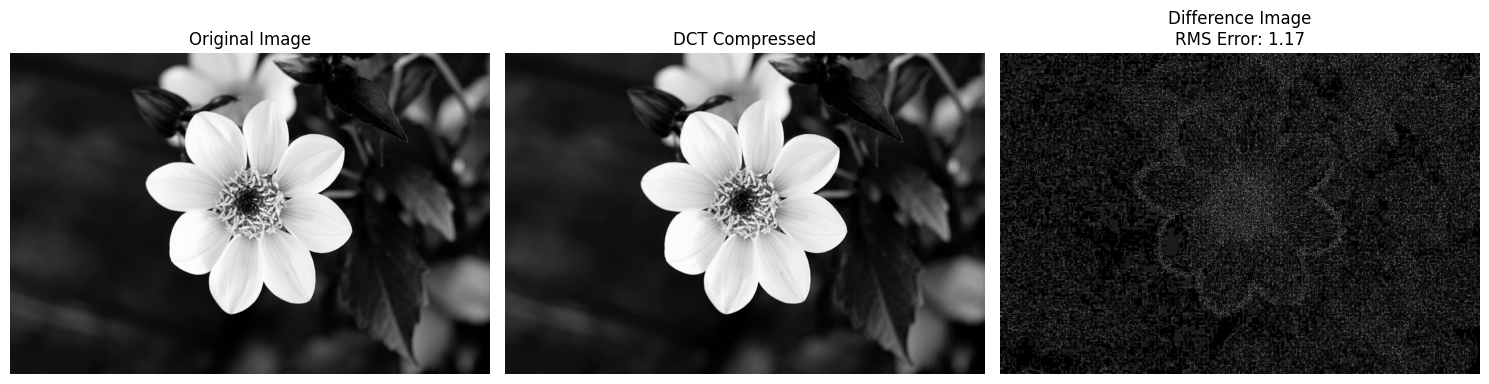

In [7]:
def dct_matrix(n):
    C=np.zeros((n,n),dtype=np.float32)
    for u in range(n):
        a=np.sqrt(1/n) if u==0 else np.sqrt(2/n)
        for x in range(n):
            C[u,x]=a*np.cos(((2*x+1)*u*np.pi)/(2*n))
    return C

def quantizer(x,s): return np.round(x/s)
def dequantizer(q,s): return q*s

def dct_transform(block):
    C=dct_matrix(block.shape[0])
    return C@block@C.T

def inverse_dct(block):
    C=dct_matrix(block.shape[0])
    return C.T@block@C

def rms_error(a,b):
    return np.sqrt(np.mean((a.astype(np.float32)-b.astype(np.float32))**2))

def dct_coding(img,block_size=8,q_step=10):
    h,w=img.shape
    h-=h%block_size; w-=w%block_size
    original=img[:h,:w]
    rec=np.zeros_like(original,dtype=np.float32)
    for i in range(0,h,block_size):
        for j in range(0,w,block_size):
            blk=original[i:i+block_size,j:j+block_size].astype(np.float32)
            t=dct_transform(blk)
            q=quantizer(t,q_step)
            dq=dequantizer(q,q_step)
            r=inverse_dct(dq)
            rec[i:i+block_size,j:j+block_size]=r
    return np.clip(rec,0,255).astype(np.uint8),original

compressed,original=dct_coding(img,8,10)
rms=rms_error(original,compressed)
diff=cv2.absdiff(original,compressed)
print("DCT RMS:",rms)
plt.figure(figsize=(15,5))
titles=["Original Image","DCT Compressed",f"Difference Image\nRMS Error: {rms:.2f}"]
for i,im in enumerate([original,compressed,diff],1):
    plt.subplot(1,3,i)
    plt.imshow(im,cmap='gray')
    plt.title(titles[i-1]); plt.axis('off')
plt.tight_layout(); 
plt.show()

## Discrete Fourier Transform

Image Size : (632, 944)
Block Size : 8
Quantization Step : 10
RMS Error : 1.9544


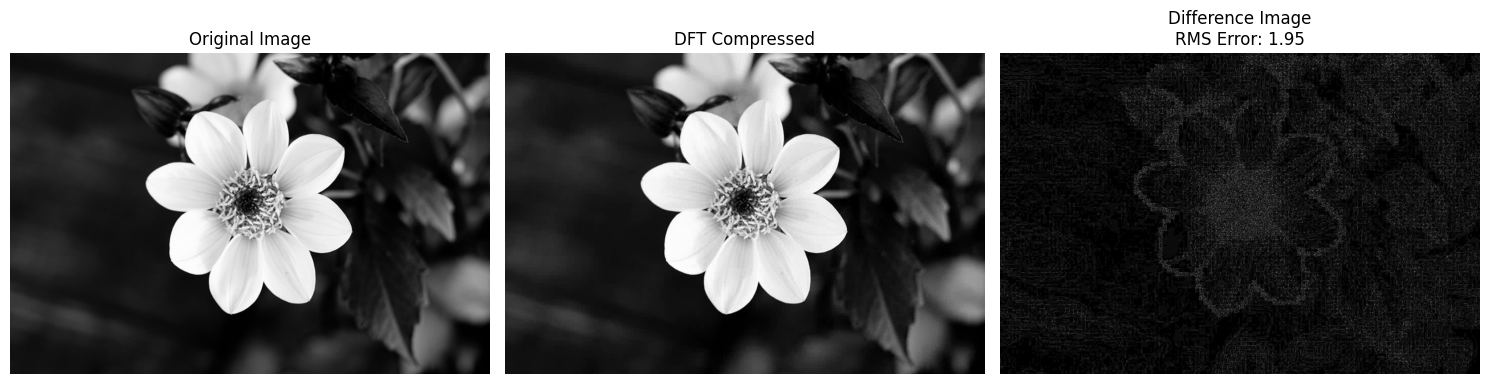

In [9]:
def dft_matrix(n):
    F = np.zeros((n, n), dtype=np.complex64)
    for u in range(n):
        for x in range(n):
            F[u, x] = np.exp(-2j * np.pi * u * x / n) / np.sqrt(n)
    return F

def quantizer(x, step):
    return np.round(x.real / step) + 1j * np.round(x.imag / step)

def dequantizer(q, step):
    return q * step

def dft_transform(block):
    F = dft_matrix(block.shape[0])
    return F @ block @ F.conj().T

def inverse_dft_transform(coeff):
    F = dft_matrix(coeff.shape[0])
    return (F.conj().T @ coeff @ F).real

def rms_error(original, reconstructed):
    return np.sqrt(np.mean((original.astype(np.float32) - reconstructed.astype(np.float32)) ** 2))

def dft_coding(img, block_size=8, q_step=10):
    h, w = img.shape
    h -= h % block_size
    w -= w % block_size

    original = img[:h, :w]
    reconstructed = np.zeros((h, w), dtype=np.float32)

    for i in range(0, h, block_size):
        for j in range(0, w, block_size):

            block = original[i:i+block_size,
                             j:j+block_size].astype(np.float32)

            coeff = dft_transform(block)

            q = quantizer(coeff, q_step)
            dq = dequantizer(q, q_step)

            rec = inverse_dft_transform(dq)

            reconstructed[i:i+block_size,
                          j:j+block_size] = rec

    reconstructed = np.clip(reconstructed, 0, 255).astype(np.uint8)

    return reconstructed, original

block_size = 8
q_step = 10

compressed, original = dft_coding(img, block_size, q_step)

rms = rms_error(original, compressed)

diff = cv2.absdiff(original, compressed)

print("Image Size :", original.shape)
print("Block Size :", block_size)
print("Quantization Step :", q_step)
print(f"RMS Error : {rms:.4f}")

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original,cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(compressed,cmap='gray')
plt.title("DFT Compressed")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(diff,cmap='gray')
plt.title(f"Difference Image\nRMS Error: {rms:.2f}")
plt.axis("off")

plt.tight_layout()
plt.show()